In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

# ---------------------------
# CONFIG (COAL ATB 2024)  -- keep consistent naming
# ---------------------------
FILE_URLS = {
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/coal_ATB_2024_moderate.csv",
    "conservative": "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/coal_ATB_2024_Conservative.csv",
    "advanced": "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/coal_ATB_2024_Advance.csv",
}

COL_CLASS = "i"
COL_YEAR = "t"
METRICS = ["capcost", "fom", "vom", "heatrate"]

START_YEAR = 2025

# ---------------------------
# SAMPLING RULES (what you asked)
# ---------------------------
SAMPLE_CLASSES = ["Coal-IGCC", "Coal-new"]
SAMPLE_METRICS = ["capcost", "fom", "vom"]     # only these have bounds
APPLY_AFTER_YEAR = 2025                        # multiply for t > 2025

N_SAMPLES = 2
RANDOM_SEED = 42

OUT_DIR = Path("coal_ATB_2024_samples")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_SAMPLES_TABLE = True
SAMPLES_TABLE_CSV = OUT_DIR / "coal_ATB_2024_sample_multipliers.csv"


# ---------------------------
# HELPERS (same as your envelope pattern)
# ---------------------------
def _clean_url(url: str) -> str:
    return url.split("#")[0]

def load_from_urls(file_urls: dict) -> pd.DataFrame:
    frames = []
    for scen, url in file_urls.items():
        url = _clean_url(url)
        tmp = pd.read_csv(url)
        tmp["scenario"] = scen
        frames.append(tmp)

    out = pd.concat(frames, ignore_index=True)
    out[COL_YEAR] = pd.to_numeric(out[COL_YEAR], errors="coerce")
    out[COL_CLASS] = out[COL_CLASS].astype(str)

    for m in METRICS:
        out[m] = pd.to_numeric(out[m], errors="coerce")

    return out.sort_values(["scenario", COL_CLASS, COL_YEAR]).reset_index(drop=True)

def fit_multiplier_ls(moderate: pd.Series, target: pd.Series) -> float:
    m = moderate.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(m, m))
    if denom == 0:
        return np.nan
    return float(np.dot(m, y) / denom)

def envelope_multipliers_for_group(df_g: pd.DataFrame, metric: str, start_year: int = 2025) -> dict:
    piv = (df_g[[COL_YEAR, "scenario", metric]]
           .dropna(subset=[COL_YEAR, metric])
           .pivot_table(index=COL_YEAR, columns="scenario", values=metric, aggfunc="mean")
           .sort_index())

    for s in ["moderate", "advanced", "conservative"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for metric='{metric}'. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"])
    if len(window) < 2:
        return {"metric": metric, "low_mult": np.nan, "high_mult": np.nan}

    mA = fit_multiplier_ls(window["moderate"], window["advanced"])
    mC = fit_multiplier_ls(window["moderate"], window["conservative"])
    return {
        "metric": metric,
        "low_mult": float(np.nanmin([mA, mC])),
        "high_mult": float(np.nanmax([mA, mC])),
        "mA": mA,
        "mC": mC,
        "n_years_fit": len(window),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def build_base_moderate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Base moderate in GitHub format: i,t,capcost,fom,vom,heatrate
    """
    base = (df[df["scenario"] == "moderate"][[COL_CLASS, COL_YEAR] + METRICS]
            .dropna(subset=[COL_CLASS, COL_YEAR])
            .sort_values([COL_CLASS, COL_YEAR])
            .reset_index(drop=True))
    return base[[COL_CLASS, COL_YEAR, "capcost", "fom", "vom", "heatrate"]]

def sample_uniform(lo: float, hi: float, rng: np.random.Generator) -> float:
    return float(rng.uniform(float(lo), float(hi)))

def apply_samples_only_after_2025(
    base: pd.DataFrame,
    class_metric_mults: dict,
    apply_after_year: int = 2025
) -> pd.DataFrame:
    """
    class_metric_mults: {(class, metric): multiplier}
    Applies only for t > apply_after_year
    Only affects SAMPLE_CLASSES & SAMPLE_METRICS (by construction)
    """
    out = base.copy()
    mask_year = out[COL_YEAR].astype(int) > int(apply_after_year)

    for cls in out[COL_CLASS].unique():
        for metric in SAMPLE_METRICS:
            key = (cls, metric)
            if key not in class_metric_mults:
                continue
            mask = (out[COL_CLASS] == cls) & mask_year
            out.loc[mask, metric] = out.loc[mask, metric] * float(class_metric_mults[key])

    # enforce exact GitHub order
    return out[[COL_CLASS, COL_YEAR, "capcost", "fom", "vom", "heatrate"]]


# ---------------------------
# RUN: load + compute bounds (only IGCC and new, only 3 metrics)
# ---------------------------
df = load_from_urls(FILE_URLS)
base = build_base_moderate(df)

# Bounds dict: (class, metric) -> (low, high)
bounds = {}
for cls in SAMPLE_CLASSES:
    df_g = df[df[COL_CLASS] == cls].copy()
    if df_g.empty:
        raise ValueError(f"Class '{cls}' not found in loaded data.")
    for metric in SAMPLE_METRICS:
        info = envelope_multipliers_for_group(df_g, metric, start_year=START_YEAR)
        bounds[(cls, metric)] = (info["low_mult"], info["high_mult"])

print("Envelope bounds used for sampling (low, high):")
for k, v in bounds.items():
    print(k, v)

# ---------------------------
# Sampling + CSV generation
# ---------------------------
rng = np.random.default_rng(RANDOM_SEED)
samples_list = []

for s in range(N_SAMPLES):
    class_metric_mults = {}

    # Sample multipliers ONLY for the specified classes/metrics
    for cls in SAMPLE_CLASSES:
        for metric in SAMPLE_METRICS:
            lo, hi = bounds[(cls, metric)]
            # If bounds missing, fall back to 1.0 (no change)
            if pd.isna(lo) or pd.isna(hi):
                mult = 1.0
            else:
                mult = sample_uniform(lo, hi, rng)
            class_metric_mults[(cls, metric)] = mult

    sampled_df = apply_samples_only_after_2025(
        base=base,
        class_metric_mults=class_metric_mults,
        apply_after_year=APPLY_AFTER_YEAR
    )

    out_path = OUT_DIR / f"coal_ATB_2024_sample_{s:03d}.csv"
    sampled_df.to_csv(out_path, index=False)

    # list-format record for this sample
    rec = {
        "sample_id": s,
        "apply_after_year": APPLY_AFTER_YEAR,
        "csv_file": str(out_path),
    }
    for cls in SAMPLE_CLASSES:
        for metric in SAMPLE_METRICS:
            rec[f"{cls}__{metric}_mult"] = class_metric_mults[(cls, metric)]
    samples_list.append(rec)

# Print a few in list format
print("\nFirst 5 samples (list format):")
for item in samples_list[:5]:
    print(item)

# Save the multipliers used for each sample
if SAVE_SAMPLES_TABLE:
    pd.DataFrame(samples_list).to_csv(SAMPLES_TABLE_CSV, index=False)
    print("\nSaved multipliers table:", SAMPLES_TABLE_CSV)

print(f"\nSaved {N_SAMPLES} sampled CSVs to: {OUT_DIR.resolve()}")


Envelope bounds used for sampling (low, high):
('Coal-IGCC', 'capcost') (0.9709497807702198, 1.0296780489253226)
('Coal-IGCC', 'fom') (0.9723723992268445, 1.0282155972604181)
('Coal-IGCC', 'vom') (0.9723925296861113, 1.028154532168085)
('Coal-new', 'capcost') (0.9738082083096965, 1.027183483327765)
('Coal-new', 'fom') (0.9770735393783395, 1.0231312834468453)
('Coal-new', 'vom') (0.9853210217457645, 1.0154415886976587)

First 5 samples (list format):
{'sample_id': 0, 'apply_after_year': 2025, 'csv_file': 'coal_ATB_2024_samples/coal_ATB_2024_sample_000.csv', 'Coal-IGCC__capcost_mult': 1.016402879130078, 'Coal-IGCC__fom_mult': 0.9968807748505841, 'Coal-IGCC__vom_mult': 1.0202696690272273, 'Coal-new__capcost_mult': 1.0110304186495485, 'Coal-new__fom_mult': 0.9814111355643995, 'Coal-new__vom_mult': 1.014707320108004}
{'sample_id': 1, 'apply_after_year': 2025, 'csv_file': 'coal_ATB_2024_samples/coal_ATB_2024_sample_001.csv', 'Coal-IGCC__capcost_mult': 1.0156501972922043, 'Coal-IGCC__fom_mult

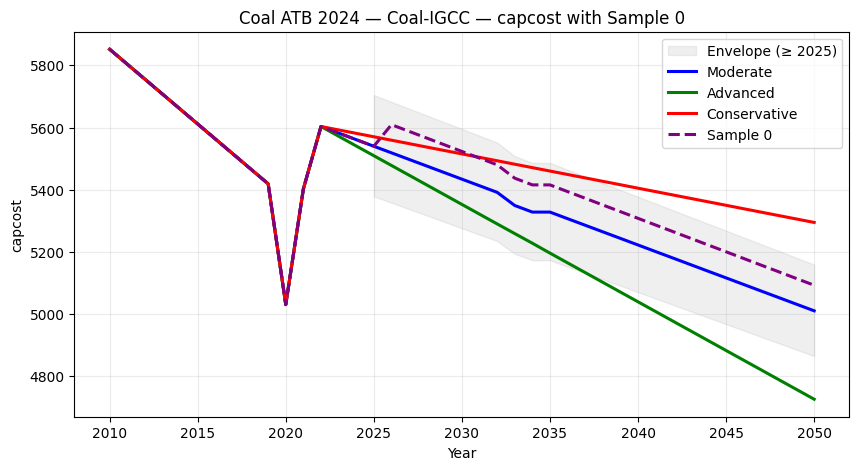

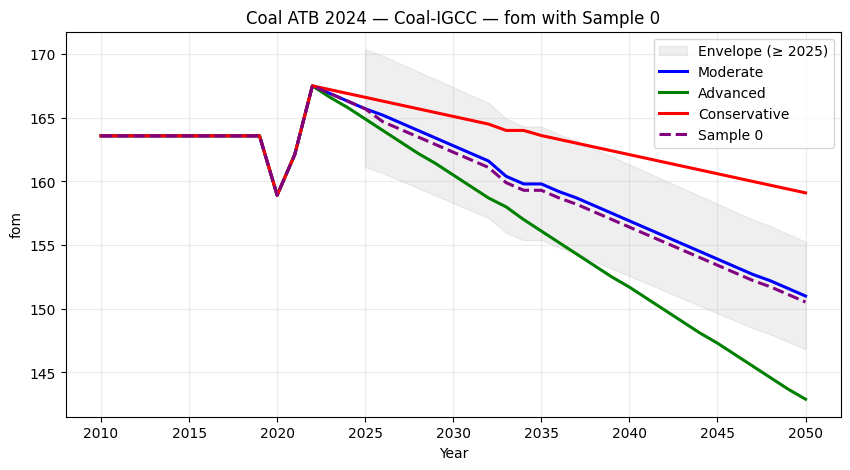

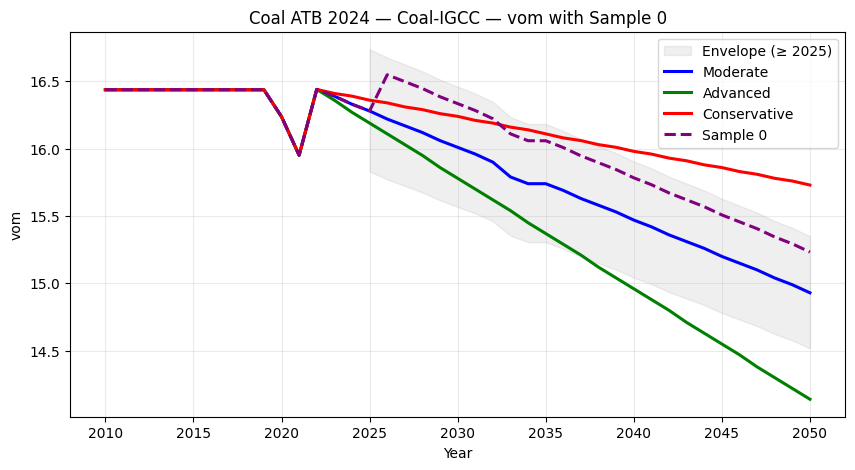

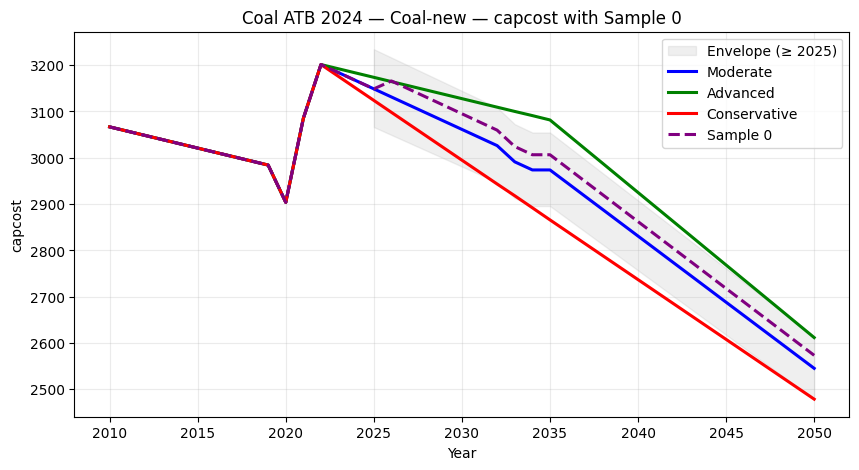

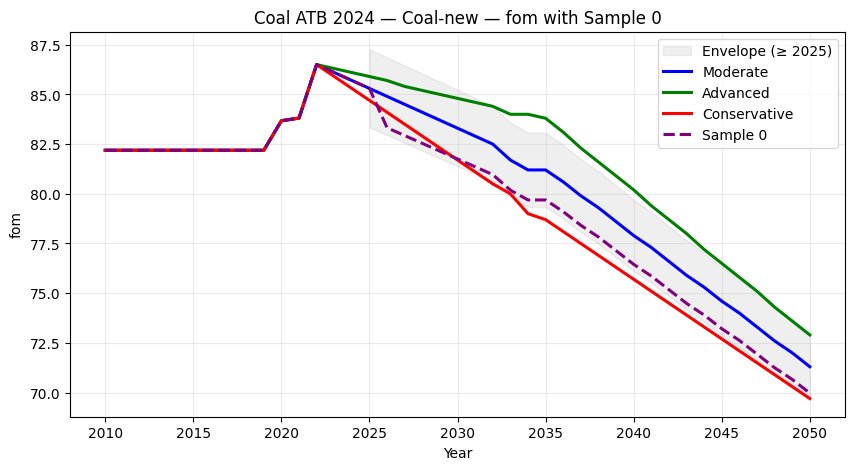

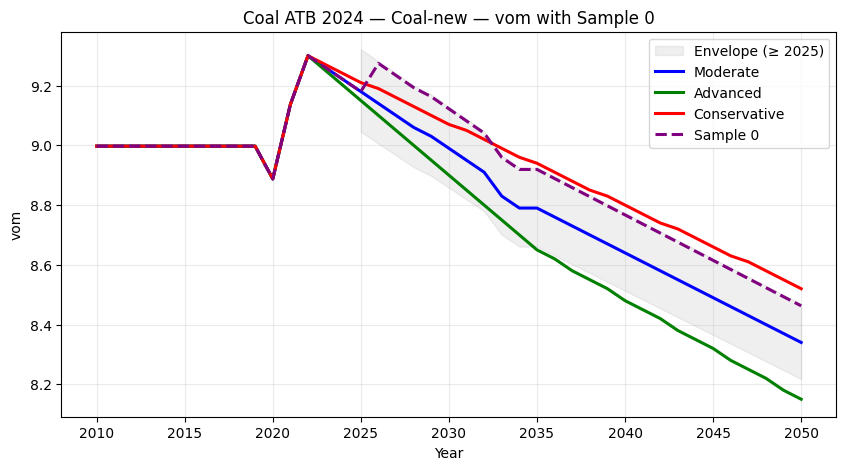

In [2]:
import matplotlib.pyplot as plt

TYPICAL_SAMPLE_ID = 0 # Selecting the first sample as 'typical'

def plot_sample_for_group(
    original_df: pd.DataFrame,
    sampled_df_single: pd.DataFrame,
    cls: str,
    metric: str,
    start_year: int = 2025
) -> None:
    """
    Plots moderate, advanced, conservative, and a single sampled trajectory.
    Also shows the envelope derived from advanced/conservative.
    """
    df_g = original_df[original_df[COL_CLASS] == cls].copy()
    info = envelope_multipliers_for_group(df_g, metric, start_year=start_year)

    piv = (df_g[[COL_YEAR, "scenario", metric]]
           .dropna(subset=[COL_YEAR, metric])
           .pivot_table(index=COL_YEAR, columns="scenario", values=metric, aggfunc="mean")
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    env_low = M_all * info["low_mult"]
    env_high = M_all * info["high_mult"]

    mask = years >= start_year
    yrs_env = years[mask]

    plt.figure(figsize=(10, 5))
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        color="grey",
        label=f"Envelope (≥ {start_year})"
    )
    plt.plot(years, piv["moderate"].values, linewidth=2.2, label="Moderate", color="blue")
    plt.plot(years, piv["advanced"].values, linewidth=2.2, label="Advanced", color="green")
    plt.plot(years, piv["conservative"].values, linewidth=2.2, label="Conservative", color="red")

    # Plot the specific sampled trajectory
    sampled_vals = sampled_df_single[(sampled_df_single[COL_CLASS] == cls)][[COL_YEAR, metric]].set_index(COL_YEAR).loc[years, metric]
    plt.plot(years, sampled_vals, linewidth=2.2, linestyle="--", color="purple", label=f"Sample {TYPICAL_SAMPLE_ID}")

    plt.title(f"Coal ATB 2024 — {cls} — {metric} with Sample {TYPICAL_SAMPLE_ID}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

# Generate multipliers for a 'typical' sample (e.g., sample 0)
rng = np.random.default_rng(RANDOM_SEED) # Use same seed as second cell
class_metric_mults = {}
for cls in SAMPLE_CLASSES:
    for metric in SAMPLE_METRICS:
        lo, hi = bounds.get((cls, metric), (np.nan, np.nan))
        if pd.isna(lo) or pd.isna(hi):
            mult = 1.0
            print(f"Warning: No valid bounds for {(cls, metric)}, using multiplier 1.0")
        else:
            mult = sample_uniform(lo, hi, rng)
        class_metric_mults[(cls, metric)] = mult

# Create a dataframe for the typical sample
typical_sampled_df = apply_samples_only_after_2025(
    base=base,
    class_metric_mults=class_metric_mults,
    apply_after_year=APPLY_AFTER_YEAR
)

# Plot for each requested class and metric
for cls in SAMPLE_CLASSES:
    for metric in SAMPLE_METRICS:
        plot_sample_for_group(df, typical_sampled_df, cls, metric, start_year=START_YEAR)


In [3]:
# bounds: dict[(cls, metric)] = (low_mult, high_mult)
# SAMPLE_CLASSES = ["Coal-IGCC", "Coal-new"]
# SAMPLE_METRICS  = ["capcost", "fom", "vom"]

# --- Units for the underlying parameters (ReEDS-style) ---
# NOTE: Multipliers themselves are unitless; these are the units of the parameters they scale.
metric_units = {
    "capcost": r"\$/MW",        # often in 2004$/MW in ReEDS
    "fom":     r"\$/MW-yr",     # often 2004$/MW-yr
    "vom":     r"\$/MWh",       # often 2004$/MWh
    "heatrate": r"MMBtu/MWh",
}

latex_rows = []
for (cls, metric), (low_mult, high_mult) in bounds.items():
    parameter = rf"{cls} -- {metric}"
    unit = metric_units.get(metric, "unitless")
    # Upperbound then Lowerbound (as you requested)
    latex_rows.append(
        rf"{parameter} & {high_mult:.4f} & {low_mult:.4f} & {unit} (multiplier) \\\\"
    )

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Sampled Multiplier Bounds and Parameter Units for Coal ATB 2024}}
\label{{tab:coal_metric_bounds_units}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display({'text/markdown': rf"""```latex
{full_latex_table}
```"""}, raw=True)

```latex

\begin{table}[h!]
\centering
\caption{Sampled Multiplier Bounds and Parameter Units for Coal ATB 2024}
\label{tab:coal_metric_bounds_units}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
Coal-IGCC -- capcost & 1.0297 & 0.9709 & \$/MW (multiplier) \\\\
Coal-IGCC -- fom & 1.0282 & 0.9724 & \$/MW-yr (multiplier) \\\\
Coal-IGCC -- vom & 1.0282 & 0.9724 & \$/MWh (multiplier) \\\\
Coal-new -- capcost & 1.0272 & 0.9738 & \$/MW (multiplier) \\\\
Coal-new -- fom & 1.0231 & 0.9771 & \$/MW-yr (multiplier) \\\\
Coal-new -- vom & 1.0154 & 0.9853 & \$/MWh (multiplier) \\\\
\bottomrule
\end{tabular}
\end{table}

```

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# Coal ATB 2024 — generate ONE ReEDS-format CSV per Morris row
#   - Uses your Morris design + factor map from GitHub
#   - Applies multipliers ONLY for years > 2025 (i.e., 2026+)
#   - ONLY changes Coal-IGCC and Coal-new for: capcost, fom, vom
#   - Preserves EXACT GitHub-style columns/order: i,t,capcost,fom,vom,heatrate
# ============================================================

# -----------------------
# (0) CONFIG
# -----------------------
APPLY_AFTER_YEAR = 2025  # "multiplication occurs after 2025" => apply for t > 2025 (2026+)

SAMPLE_CLASSES = ["Coal-IGCC", "Coal-new"]
SAMPLE_METRICS = ["capcost", "fom", "vom"]

MORRIS_DESIGN_URL = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv#/"
FACTOR_MAP_URL    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv#/"

OUT_DIR = Path("coal_ATB_2024_morris_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_SAMPLES_TABLE = True
MANIFEST_CSV = OUT_DIR / "coal_ATB_2024_morris_manifest.csv"

# -----------------------
# (1) LOAD MORRIS FILES
# -----------------------
design = pd.read_csv(MORRIS_DESIGN_URL)
factor_map = pd.read_csv(FACTOR_MAP_URL)

# -----------------------
# (2) BUILD / LOAD BASE MODERATE TABLE (GitHub format)
#     You already have these in your notebook from earlier cells:
#       df = load_from_urls(FILE_URLS)
#       base = build_base_moderate(df)
#
#     If `base` already exists, we use it directly.
# -----------------------
if "base" not in globals():
    raise NameError(
        "I expected `base` to already exist (built from the MODERATE scenario). "
        "Run your earlier cells that create: df = load_from_urls(FILE_URLS); base = build_base_moderate(df)."
    )

# Validate base columns/order EXACTLY as ReEDS expects for coal plant_characteristics
EXPECTED_COLS = ["i", "t", "capcost", "fom", "vom", "heatrate"]
missing = [c for c in EXPECTED_COLS if c not in base.columns]
if missing:
    raise ValueError(f"`base` is missing required columns: {missing}. Found: {list(base.columns)}")

base = base.copy()
base["t"] = pd.to_numeric(base["t"], errors="raise").astype(int)

# Enforce exact column order in the base itself (prevents downstream surprises)
base = base[EXPECTED_COLS].sort_values(["i", "t"]).reset_index(drop=True)

# -----------------------
# (3) APPLY MULTIPLIERS ONLY AFTER 2025
# -----------------------
def apply_samples_only_after_2025(base_df: pd.DataFrame, class_metric_mults: dict, apply_after_year: int = 2025) -> pd.DataFrame:
    """
    class_metric_mults: {(class, metric): multiplier}
    Applies only for t > apply_after_year (i.e., 2026+ if apply_after_year=2025)
    Only affects SAMPLE_CLASSES & SAMPLE_METRICS (by construction)
    """
    out = base_df.copy()
    mask_year = out["t"].astype(int) > int(apply_after_year)

    for cls in SAMPLE_CLASSES:
        for metric in SAMPLE_METRICS:
            key = (cls, metric)
            if key not in class_metric_mults:
                continue
            mask = (out["i"] == cls) & mask_year
            out.loc[mask, metric] = out.loc[mask, metric].astype(float) * float(class_metric_mults[key])

    # enforce exact GitHub order
    return out[EXPECTED_COLS].sort_values(["i", "t"]).reset_index(drop=True)

# -----------------------
# (4) FIND THE MORRIS DESIGN COLUMN NAMES FOR OUR COAL FACTORS
#     We support multiple naming styles automatically:
#       A) "Coal-IGCC__capcost"  (recommended)
#       B) "Coal-IGCC -- capcost"
#       C) anything where factor_map['parameter'] contains those strings
# -----------------------
def _norm(s: str) -> str:
    return str(s).strip().lower().replace("_", " ").replace("-", "-")

# Build a lookup: (cls, metric) -> design_column_name
col_lookup = {}

design_cols_lower = {c.lower(): c for c in design.columns}

# Helper: try to match a desired factor using common patterns
def resolve_design_column(cls: str, metric: str) -> str | None:
    candidates = [
        f"{cls}__{metric}",
        f"{cls}--{metric}",
        f"{cls} -- {metric}",
        f"{cls}_{metric}",
        f"{cls} {metric}",
    ]
    # direct design-column match (case-insensitive)
    for cand in candidates:
        if cand.lower() in design_cols_lower:
            return design_cols_lower[cand.lower()]

    # use factor_map if it has a 'parameter' or similar descriptive column
    # common schemas we’ve used:
    #   factor_map columns: ['factor','parameter','Lowerbound','Upperbound',...]
    for param_col in ["parameter", "Parameter", "name", "Name", "desc", "description"]:
        if param_col in factor_map.columns:
            # locate row in factor_map whose parameter matches our cls/metric
            mask = (
                factor_map[param_col].astype(str).str.contains(cls, case=False, na=False)
                & factor_map[param_col].astype(str).str.contains(metric, case=False, na=False)
            )
            hits = factor_map.loc[mask]
            if len(hits) >= 1:
                # the actual design column should be the factor name
                for factor_col in ["factor", "Factor", "id", "ID"]:
                    if factor_col in factor_map.columns:
                        f = str(hits.iloc[0][factor_col])
                        if f.lower() in design_cols_lower:
                            return design_cols_lower[f.lower()]
                        # sometimes factor map factor uses different case; try direct exact
                        if f in design.columns:
                            return f
            break

    return None

# Resolve all needed columns
missing_factors = []
for cls in SAMPLE_CLASSES:
    for metric in SAMPLE_METRICS:
        dc = resolve_design_column(cls, metric)
        if dc is None:
            missing_factors.append(f"{cls}::{metric}")
        else:
            col_lookup[(cls, metric)] = dc

if missing_factors:
    raise ValueError(
        "Could not find Morris design columns for these factors:\n"
        f"  {missing_factors}\n\n"
        "Fix by renaming your Morris design columns to one of these patterns:\n"
        "  Coal-IGCC__capcost, Coal-IGCC__fom, Coal-IGCC__vom,\n"
        "  Coal-new__capcost, Coal-new__fom, Coal-new__vom\n\n"
        f"Design columns found (first 30): {list(design.columns)[:30]}"
    )

print("Resolved Morris design columns for Coal factors:")
for k, v in col_lookup.items():
    print(f"  {k} -> {v}")

# -----------------------
# (5) GENERATE ONE CSV PER MORRIS ROW
# -----------------------
manifest = []

for ridx, row in design.reset_index(drop=True).iterrows():
    class_metric_mults = {}

    # Fill multipliers for just IGCC & new and just (capcost,fom,vom)
    for cls in SAMPLE_CLASSES:
        for metric in SAMPLE_METRICS:
            dcol = col_lookup[(cls, metric)]
            mult = float(row[dcol])

            # If any NA slips in, default to 1.0 (no change)
            if pd.isna(mult):
                mult = 1.0
            class_metric_mults[(cls, metric)] = mult

    df_out = apply_samples_only_after_2025(
        base_df=base,
        class_metric_mults=class_metric_mults,
        apply_after_year=APPLY_AFTER_YEAR
    )

    fname = f"coal_ATB_2024_morris_{ridx:03d}.csv"
    fpath = OUT_DIR / fname
    df_out.to_csv(fpath, index=False)

    rec = {
        "morris_row": ridx,
        "file": fname,
        "apply_after_year": APPLY_AFTER_YEAR,
    }
    for cls in SAMPLE_CLASSES:
        for metric in SAMPLE_METRICS:
            rec[f"{cls}__{metric}_mult"] = class_metric_mults[(cls, metric)]
    manifest.append(rec)

manifest_df = pd.DataFrame(manifest)
if SAVE_SAMPLES_TABLE:
    manifest_df.to_csv(MANIFEST_CSV, index=False)

print(f"\nDone. Wrote {len(manifest_df)} files to: {OUT_DIR.resolve()}")
print(f"Saved manifest: {MANIFEST_CSV}")
print("\nPreview first output:")
display(pd.read_csv(OUT_DIR / "coal_ATB_2024_morris_000.csv").head(20))

# -----------------------
# (6) OPTIONAL: STRICT VALIDATION AGAINST BASE
#     Ensures columns + order match EXACTLY (prevents ReEDS errors).
# -----------------------
def validate_against_base(path_csv: Path, base_cols: list[str]) -> None:
    tmp = pd.read_csv(path_csv)
    if list(tmp.columns) != base_cols:
        raise ValueError(
            f"Column mismatch in {path_csv.name}\n"
            f"Expected: {base_cols}\n"
            f"Found:    {list(tmp.columns)}"
        )

# validate a couple
validate_against_base(OUT_DIR / "coal_ATB_2024_morris_000.csv", EXPECTED_COLS)
validate_against_base(OUT_DIR / f"coal_ATB_2024_morris_{len(manifest_df)-1:03d}.csv", EXPECTED_COLS)
print("\nValidation passed (columns/order match base).")


Resolved Morris design columns for Coal factors:
  ('Coal-IGCC', 'capcost') -> coal_igcc_capcost
  ('Coal-IGCC', 'fom') -> coal_igcc_fom
  ('Coal-IGCC', 'vom') -> coal_igcc_vom
  ('Coal-new', 'capcost') -> coal_new_capcost
  ('Coal-new', 'fom') -> coal_new_fom
  ('Coal-new', 'vom') -> coal_new_vom

Done. Wrote 200 files to: /content/coal_ATB_2024_morris_outputs
Saved manifest: coal_ATB_2024_morris_outputs/coal_ATB_2024_morris_manifest.csv

Preview first output:


,i,t,capcost,fom,vom,heatrate
0,Coal-IGCC,2010,5851.647055,163.575971,16.437725,9.325000
1,Coal-IGCC,2011,5803.570143,163.575971,16.437725,9.239333
2,Coal-IGCC,2012,5755.493231,163.575971,16.437725,9.153667
3,Coal-IGCC,2013,5707.416318,163.575971,16.437725,9.068000
4,Coal-IGCC,2014,5659.339405,163.575971,16.437725,8.982333
5,Coal-IGCC,2015,5611.262494,163.575971,16.437725,8.896667
6,Coal-IGCC,2016,5563.185581,163.575971,16.437725,8.811000
7,Coal-IGCC,2017,5515.108668,163.575971,16.437725,8.725333
8,Coal-IGCC,2018,5467.031756,163.575971,16.437725,8.639667
9,Coal-IGCC,2019,5418.954843,163.575971,16.437725,8.554000



Validation passed (columns/order match base).


In [5]:
from pathlib import Path
import shutil

OUT_DIR = Path("coal_ATB_2024_morris_outputs")  # <- must match your script
zip_name = "coal_ATB_2024_morris_outputs"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: coal_ATB_2024_morris_outputs.zip
